## Bibliotecas e GPU

In [1]:
# Bibliotecas
import os
import random
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

from funcs import modificacoes1, banco, tvt, modificacoes2
from redes.unet import unet 
from redes.unet_fuzzy import  unet_fuzzy

from redes.fuzzy_layer import (
    FuzzyBottleneckModule,
    FuzzificationLayer,
    FuzzyInferenceLayer,
    DefuzzificationLayer,
)


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, dtype=np.float32)


I0000 00:00:1774879423.515264   30004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774879423.624817   30004 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774879425.873288   30004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Configuração (GPU / mixed precision / strategy)

print('TensorFlow:', tf.__version__)
print('Built with CUDA:', tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices('GPU')
cpus = tf.config.list_physical_devices('CPU')
print('GPUs:', gpus)
print('CPUs:', cpus)

# Importante: fazer isso ANTES de criar modelos/estratégias, para evitar reservar toda a VRAM
if gpus:
    for g in gpus:
        try:
            tf.config.experimental.set_memory_growth(g, True)
        except Exception as e:
            print('Não foi possível habilitar memory growth:', e)

    # Mixed precision costuma reduzir MUITO o uso de VRAM em U-Net
    mixed_precision.set_global_policy('mixed_float16')
    print('Mixed precision policy:', mixed_precision.global_policy())

# Estratégia: só use MirroredStrategy se tiver >1 GPU
strategy = tf.distribute.MirroredStrategy() if len(gpus) > 1 else tf.distribute.get_strategy()
print('Strategy:', type(strategy).__name__)

TensorFlow: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">
Strategy: _DefaultDistributionStrategy


In [3]:
# Mais detalhes de GPU
# Se quiser ver detalhes, rode este bloco.
gpus = tf.config.list_physical_devices('GPU')
for i, g in enumerate(gpus):
    try:
        details = tf.config.experimental.get_device_details(g)
    except Exception as e:
        details = {'error': str(e)}
    print(f'GPU {i}:', g, 'details:', details)

GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU') details: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}


## Montando o Banco de dados

In [4]:
""" Renomeia os arquivos do label_studio """
# path_y_train = 'banco2/Nelore2/label_studio'
# path_x_train = 'banco2/Nelore2/img_corte'
# y_destino = 'banco2/Nelore2/label_egl'
# lista_img_train = sorted(os.listdir(path_x_train))
# lista_img_label = sorted(os.listdir(path_y_train))
# print(lista_img_label)

# for i,nome_arquivo in enumerate(lista_img_label):
#     caminho = os.path.join(path_y_train, nome_arquivo)
#     img = cv2.imread(caminho)

#     nome_limpo, ext = os.path.splitext(lista_img_train[i])
#     novo_nome = f'{nome_limpo}.jpg'
#     destino = os.path.join(y_destino, novo_nome)
#     cv2.imwrite(destino, img)

' Renomeia os arquivos do label_studio '

In [5]:
path_x_train = 'banco2/TreinoGeral/AOL/imgs'
path_y_train = 'banco2/TreinoGeral/AOL/labels'

x_train, nomes_train = banco(path_x_train, resolution=(256,256), grayscale= True, nomes=True)
y_train, labels_train = banco(path_y_train, resolution=(256,256), grayscale= True, nomes=True)

print(f'Tamanho x_train: {x_train.shape}, y_train: {y_train.shape}')

Tamanho x_train: (135, 256, 256, 1), y_train: (135, 256, 256, 1)


In [6]:
""" Visualizando algumas imagens e labels """
def plot_img_mask(img_list, mask_list, num_pairs = 5, label = None):
    n = num_pairs
    plt.figure(figsize=(10, 6))
    for i in range(n):
        idx = random.randint(0, len(img_list) - 1)
        img = img_list[idx]
        mask = mask_list[idx]
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        if label is not None and len(label) > idx:
            plt.title(f"Imagem = {label[idx][2:6]}, index =  {idx}", fontsize=9)
        plt.axis("off")

        plt.subplot(2, n, i + 1 + n)
        plt.imshow(mask)
        if label is not None and len(label) > idx:
            plt.title(f"Label = {label[idx][2:6]}, index = {idx}", fontsize=9)
        plt.axis("off")
        del img, mask

In [7]:
""" Função tvt: train, val, test """
x_train, y_train, nomes_train, x_val, y_val, nomes_val, x_test, y_test, nomes_test = tvt(x_train, y_train, partition=(0.7, 0.2, 0.1), nomes = nomes_train) # 70% treino, 20% validação, 10% teste

In [8]:
# Prints de verificação dos conjuntos
print(f'Imagens X treino: {x_train.shape}')
print(f'Imagens Y treino: {y_train.shape}')
print(f'Nomes treino: {len(nomes_train)}')

print(f'Imagens X teste: {x_test.shape}')
print(f'Imagens Y teste: {y_test.shape}')
print(f'Nomes teste: {len(nomes_test)}')

print(f'Imagens X validação: {x_val.shape}')
print(f'Imagens Y validação: {y_val.shape}')
print(f'Nomes validação: {len(nomes_val)}')

Imagens X treino: (94, 256, 256, 1)
Imagens Y treino: (94, 256, 256, 1)
Nomes treino: 94
Imagens X teste: (14, 256, 256, 1)
Imagens Y teste: (14, 256, 256, 1)
Nomes teste: 14
Imagens X validação: (27, 256, 256, 1)
Imagens Y validação: (27, 256, 256, 1)
Nomes validação: 27


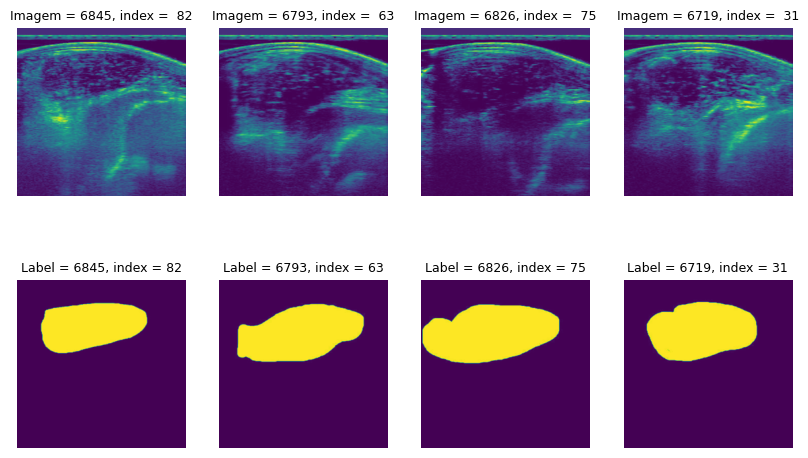

In [9]:
# Plot da função
plot_img_mask(x_train, y_train, num_pairs= 4, label= labels_train)

In [10]:
""" Modifica o banco de dados"""
# x_train
# Função para fazer as modificações nas imagens
dict_x_train, x_train_m = modificacoes1(x_train, 
             nomes_train, 
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

dict_x_val, x_val_m = modificacoes1(x_val,
             nomes_val,
             original = True, 
             brilho = 1.7,
             escura= 0.5,
             rotacao=[-30,30])

print(f'Quantidade de chaves em dict_x_train: {len(dict_x_train.keys())}')
print(f'Quantidade de valores em dict_x_train: {len(dict_x_train.values())}')

Quantidade de chaves em dict_x_train: 376
Quantidade de valores em dict_x_train: 376


In [11]:
# Modificando as labels
y_train_m = dict(zip(nomes_train, y_train))
y_val_m = dict(zip(nomes_val, y_val))
print(f'Quantidade de chaves em y_train: {len(y_train_m)}')   
print(f'Quantidade de chaves em y_val: {len(y_val_m)}')   

Quantidade de chaves em y_train: 94
Quantidade de chaves em y_val: 27


In [12]:
# # # y_train
## duplica imagens de label se necessario
y_train_m, y_train_nomes = modificacoes2(y_train_m, dict_x_train.keys())
y_val_m, y_val_nomes = modificacoes2(y_val_m, dict_x_val.keys())

In [13]:
print(len(dict_x_train.keys()))
print(len(y_train_nomes))

376
376


In [14]:
x_train_m = np.array(x_train_m)
y_train_m = np.array(y_train_m)

x_val_m = np.array(x_val_m)
y_val_m = np.array(y_val_m)

In [15]:
print(f"Quantidade de imagens em x_train_modificado: {x_train_m.shape}")
print(f"Quantidade de imagens em y_train_modificado: {y_train_m.shape}")

print(f"Quantidade de imagens em x_val_modificado: {x_val_m.shape}")
print(f"Quantidade de imagens em y_val_modificado: {y_val_m.shape}")

Quantidade de imagens em x_train_modificado: (376, 256, 256, 1)
Quantidade de imagens em y_train_modificado: (376, 256, 256, 1)
Quantidade de imagens em x_val_modificado: (108, 256, 256, 1)
Quantidade de imagens em y_val_modificado: (108, 256, 256, 1)


In [16]:
print(y_train_nomes[11][2:3])
# print(dict_x_train.keys())

2


## Criando classes para trabalhar com a Unet condicional

In [19]:
class_train = np.array([0 if nome[2:3] == '6'  else 1 for nome in y_train_nomes], dtype=np.float32)
print(len(class_train))

class_val = np.array([0 if nome[2:3] == '6'  else 1 for nome in y_val_nomes], dtype=np.float32)
print(len(class_val))

class_test = np.array([0 if nome[2:3] == '6'  else 1 for nome in nomes_test], dtype=np.float32)
print(len(class_test))

376
108
14


In [20]:
# Na célula de classes

class_train = enc.fit_transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in y_train_nomes]).reshape(-1, 1)
)
class_val = enc.transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in y_val_nomes]).reshape(-1, 1)
)
class_test = enc.transform(
    np.array([0 if nome[2:3] == '6' else 1 for nome in nomes_test]).reshape(-1, 1)
)
# class_train.shape → (N, 2)
print(class_test)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


## Salvando x_val para testes futuros

In [21]:
# Pasta base de saída
out_base = "banco2/TreinoGeral/AOL/validacaoUnetFuzzyClasses"
out_x = os.path.join(out_base, "x_test")
out_y = os.path.join(out_base, "y_test")
os.makedirs(out_x, exist_ok=True)
os.makedirs(out_y, exist_ok=True)

def to_uint8(img):
    """Converte imagem para uint8 [0,255], tratando float/bool e canal único."""
    arr = np.squeeze(img)  # remove canal extra (H,W,1) -> (H,W)
    if arr.dtype == np.bool_:
        arr = arr.astype(np.uint8) * 255
    elif np.issubdtype(arr.dtype, np.floating):
        # Se estiver normalizada em [0,1], escala para [0,255]
        arr = np.clip(arr, 0, 1)
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)
    return arr

for i in range(len(x_test)):
    nome_base = nomes_test[i] if "nomes_test" in globals() and i < len(nomes_test) else f"img_{i:04d}"
    nome_base = os.path.splitext(os.path.basename(str(nome_base)))[0]

    img_x = to_uint8(x_test[i])
    img_y = to_uint8(y_test[i])

    cv2.imwrite(os.path.join(out_x, f"{nome_base}.jpg"), img_x)
    cv2.imwrite(os.path.join(out_y, f"{nome_base}.jpg"), img_y)

print(f"Salvo em: {os.path.abspath(out_base)}")
print(f"Total de pares salvos: {len(x_test)}")

Salvo em: /home/victors/Documents/Codigos_Mestrado/banco2/TreinoGeral/AOL/validacaoUnetFuzzyClasses
Total de pares salvos: 14


## Métricas & Funções

In [22]:
# Converting the arrays into tf.data batches (mais leve e eficiente)
import gc
AUTOTUNE = tf.data.AUTOTUNE

# Se ainda der OOM, o 1o ajuste e reduzir batch_size
batch_size = 1

In [23]:
""" setting DICE coefficient to evaluate the model """
def dice_coefficient(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Flatten per-sample to compute Dice over all pixels
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)
    dice_coeff = (2.0 * intersection + smooth) / (union + smooth)
    return dice_coeff

In [24]:
""" setting DICE loss to train the model"""

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

In [25]:
""" Função: calcular área (predição vs máscara) na dimensão original (403x333) """
def comparar_area_predicao(
    idx,
    model,
    x_imgs,
    y_masks,
    nomes_dados = None,
    orig_size=(403, 333),
    threshold=0.5,
    px_per_cm=24.05,
    smooth=1e-6,
    plot=False,
    overlay_alpha=0.35,
    contours=True,
    verbose=True,
 ):
    """
    Compara a área da predição com a máscara verdadeira na dimensão original.

    Observação: se x_imgs/y_masks estiverem em 256x256 (por causa do pre-processamento),
    a comparação em 403x333 é feita via resize NEAREST para manter máscara binária.

    Retorna um dicionário com áreas (px² e cm²), diferença e métricas (Dice/IoU).
    """
    orig_h, orig_w = orig_size  # (H, W)
    cm2_per_px2 = 1.0 / (px_per_cm ** 2)
    # Pega amostra
    x = x_imgs[idx]
    y_true = y_masks[idx]
    # Predição (probabilidade)
    x_in = tf.expand_dims(x, axis=0)
    y_pred = model.predict(x_in, verbose=0)
    y_pred = np.squeeze(y_pred)
    # Binariza
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)
    y_true = np.squeeze(y_true)
    # Se a máscara veio como 0..255, normaliza implicitamente via threshold
    y_true_bin = (y_true >= threshold).astype(np.uint8)
    # Garante 2D
    if y_pred_bin.ndim == 3:
        y_pred_bin = np.squeeze(y_pred_bin)
    if y_true_bin.ndim == 3:
        y_true_bin = np.squeeze(y_true_bin)
    # Resize para dimensão original (OpenCV usa (W,H))
    pred_orig = cv2.resize(y_pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    true_orig = cv2.resize(y_true_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    # Áreas (px²) e (cm²)
    area_pred_px = int(pred_orig.sum())
    area_true_px = int(true_orig.sum())
    area_pred_cm2 = area_pred_px * cm2_per_px2
    area_true_cm2 = area_true_px * cm2_per_px2
    diff_px = area_pred_px - area_true_px
    diff_cm2 = diff_px * cm2_per_px2
    perc_diff = (100.0 * diff_px / area_true_px) if area_true_px > 0 else np.nan
    # Métricas na dimensão original
    intersection = int((pred_orig & true_orig).sum())
    union = int((pred_orig | true_orig).sum())
    dice = (2.0 * intersection + smooth) / (area_pred_px + area_true_px + smooth)
    iou = (intersection + smooth) / (union + smooth)
    result = {
        'idx': idx,
        'orig_size': (orig_h, orig_w),
        'threshold': float(threshold),
        'px_per_cm': float(px_per_cm),
        'area_pred_px2': area_pred_px,
        'area_true_px2': area_true_px,
        'area_pred_cm2': float(area_pred_cm2),
        'area_true_cm2': float(area_true_cm2),
        'diff_px2': int(diff_px),
        'diff_cm2': float(diff_cm2),
        'perc_diff_%': float(perc_diff) if not np.isnan(perc_diff) else np.nan,
        'dice_orig': float(dice),
        'iou_orig': float(iou),
    }
    if verbose:
        print(
            f"idx={idx} | area_demarcada={area_true_cm2:.3f} cm² | "
            f"area_pred={area_pred_cm2:.3f} cm² | diff={np.abs(diff_cm2):+.3f} cm² | "
            f"dice={dice:.4f} | iou={iou:.4f}"
        )
    if plot:
        img = np.squeeze(x)
        # Mostra na dimensão do modelo (p/ referência) e overlays na dimensão original
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        if nomes_dados is not None and len(nomes_dados) > idx:
            plt.title(f'Imagem (modelo) idx={idx} | {nomes_dados[idx][2:6]}')
        else:
            plt.title(f'Imagem (modelo) idx={idx}')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(true_orig, cmap='gray')
        plt.title(f'Máscara demarcada (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(pred_orig, cmap='gray')
        plt.title(f'Máscara predita (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.show()
        # Overlay (opcional)
        plt.figure(figsize=(7, 7))
        plt.imshow(cv2.resize(img, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR), cmap='gray') # Plano de fundo
        plt.imshow(true_orig, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        plt.imshow(pred_orig, cmap='Blues', alpha=overlay_alpha, vmin=0, vmax=1)
        if contours:
            try:
                plt.contour(true_orig, levels=[0.5], colors='red', linewidths=1)
                plt.contour(pred_orig, levels=[0.5], colors='deepskyblue', linewidths=1)
            except Exception:
                pass
        plt.title(f'Overlay (orig) idx={idx} | demarcada=vermelho | pred=azul')
        plt.axis('off')
        plt.show()
    return result


In [26]:
def comparar_area_predicao_multitask(
    idx,
    model,
    x_imgs,
    y_masks,
    nomes_dados = None,
    orig_size=(403, 333),
    threshold=0.5,
    px_per_cm=24.05,
    smooth=1e-6,
    plot=False,
    overlay_alpha=0.35,
    contours=True,
    verbose=True,
 ):
    """
    Compara a área da predição com a máscara verdadeira na dimensão original.

    Observação: se x_imgs/y_masks estiverem em 256x256 (por causa do pre-processamento),
    a comparação em 403x333 é feita via resize NEAREST para manter máscara binária.

    Retorna um dicionário com áreas (px² e cm²), diferença e métricas (Dice/IoU).
    """
    orig_h, orig_w = orig_size  # (H, W)
    cm2_per_px2 = 1.0 / (px_per_cm ** 2)
    # Pega amostra
    x = x_imgs[0][idx]
    x_class = x_imgs[1][idx]
    y_true = y_masks[idx]
    # Predição (probabilidade)
    x_in = tf.expand_dims(x, axis=0)
    x_class_in = tf.expand_dims(x_class, axis=0)
    y_pred = model.predict((x_in, x_class_in), verbose=0)
    y_pred = np.squeeze(y_pred)
    # Binariza
    y_pred_bin = (y_pred >= threshold).astype(np.uint8)
    y_true = np.squeeze(y_true)
    # Se a máscara veio como 0..255, normaliza implicitamente via threshold
    y_true_bin = (y_true >= threshold).astype(np.uint8)
    # Garante 2D
    if y_pred_bin.ndim == 3:
        y_pred_bin = np.squeeze(y_pred_bin)
    if y_true_bin.ndim == 3:
        y_true_bin = np.squeeze(y_true_bin)
    # Resize para dimensão original (OpenCV usa (W,H))
    pred_orig = cv2.resize(y_pred_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    true_orig = cv2.resize(y_true_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST_EXACT)
    # Áreas (px²) e (cm²)
    area_pred_px = int(pred_orig.sum())
    area_true_px = int(true_orig.sum())
    area_pred_cm2 = area_pred_px * cm2_per_px2
    area_true_cm2 = area_true_px * cm2_per_px2
    diff_px = np.abs(area_pred_px - area_true_px)
    diff_cm2 = diff_px * cm2_per_px2
    perc_diff = (100.0 * diff_px / area_true_px) if area_true_px > 0 else np.nan
    # Métricas na dimensão original
    intersection = int((pred_orig & true_orig).sum())
    union = int((pred_orig | true_orig).sum())
    dice = (2.0 * intersection + smooth) / (area_pred_px + area_true_px + smooth)
    iou = (intersection + smooth) / (union + smooth)
    #Nelore&Caracu
    if x_class[0] == 0:
        x_class_str = 'Nelore'
    elif x_class[1] == 0:
        x_class_str = 'Caracu'
    
    result = {
        'idx': idx,
        'orig_size': (orig_h, orig_w),
        'threshold': float(threshold),
        'px_per_cm': float(px_per_cm),
        'area_pred_px2': area_pred_px,
        'area_true_px2': area_true_px,
        'area_pred_cm2': float(area_pred_cm2),
        'area_true_cm2': float(area_true_cm2),
        'diff_px2': int(diff_px),
        'diff_cm2': float(diff_cm2),
        'perc_diff_%': float(perc_diff) if not np.isnan(perc_diff) else np.nan,
        'dice_orig': float(dice),
        'iou_orig': float(iou),
    }
    if verbose:
        print(
            f"idx={idx} | area_demarcada={area_true_cm2:.3f} cm² | "
            f"area_pred={area_pred_cm2:.3f} cm² | diff={np.abs(diff_cm2):+.3f} cm² | "
            f"dice={dice:.4f} | iou={iou:.4f} | "
            f"classe={x_class_str}"
        )
    if plot:
        img = np.squeeze(x)
        # Mostra na dimensão do modelo (p/ referência) e overlays na dimensão original
        plt.figure(figsize=(14, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(img, cmap='gray')
        if nomes_dados is not None and len(nomes_dados) > idx:
            plt.title(f'Imagem (modelo) idx={idx} | {nomes_dados[idx][2:6]}')
        else:
            plt.title(f'Imagem (modelo) idx={idx}')
        plt.axis('off')
        plt.subplot(1, 3, 2)
        plt.imshow(true_orig, cmap='gray')
        plt.title(f'Máscara demarcada (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.subplot(1, 3, 3)
        plt.imshow(pred_orig, cmap='gray')
        plt.title(f'Máscara predita (orig {orig_h}x{orig_w})')
        plt.axis('off')
        plt.show()
        # Overlay (opcional)
        plt.figure(figsize=(7, 7))
        plt.imshow(cv2.resize(img, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR), cmap='gray') # Plano de fundo
        plt.imshow(true_orig, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        plt.imshow(pred_orig, cmap='Blues', alpha=overlay_alpha, vmin=0, vmax=1)
        if contours:
            try:
                plt.contour(true_orig, levels=[0.5], colors='red', linewidths=1)
                plt.contour(pred_orig, levels=[0.5], colors='deepskyblue', linewidths=1)
            except Exception:
                pass
        plt.title(f'Overlay (orig) idx={idx} | demarcada=vermelho | pred=azul')
        plt.axis('off')
        plt.show()
    return result

## Modelos

In [27]:
shuffle_buffer = min(256, len(x_train_m))

# Evita float64 acidental em RAM
x_train_m = x_train_m.astype(np.float32, copy=False)
y_train_m = y_train_m.astype(np.float32, copy=False)
x_val_m = x_val_m.astype(np.float32, copy=False)
y_val_m = y_val_m.astype(np.float32, copy=False)
x_val = x_val.astype(np.float32, copy=False)
y_val = y_val.astype(np.float32, copy=False)

"""Para a Unet padrão"""
# train_data = tf.data.Dataset.from_tensor_slices((x_train_m, y_train_m))
# train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
# train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

# val_data = tf.data.Dataset.from_tensor_slices((x_val_m, y_val_m))
# val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

# test_data = tf.data.Dataset.from_tensor_slices((x_test, y_test))
# test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)

"""Para Unet com classificação"""
train_data = tf.data.Dataset.from_tensor_slices(((x_train_m, class_train), y_train_m))
train_data = train_data.shuffle(buffer_size=shuffle_buffer, seed=42, reshuffle_each_iteration=True)
train_data = train_data.batch(batch_size).prefetch(AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(((x_val_m, class_val), y_val_m))
val_data = val_data.batch(batch_size).prefetch(AUTOTUNE)

test_data = tf.data.Dataset.from_tensor_slices(((x_test, class_test), y_test))
test_data = test_data.batch(batch_size).prefetch(AUTOTUNE)



print(f"Exemplos por batch: {batch_size}")
print(f"Total de batches em treino: {len(train_data)}")
print(f"Total de batches em validação: {len(val_data)}")
print(f"Total de batches em teste: {len(test_data)}")

I0000 00:00:1774879444.031070   30004 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1731 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Exemplos por batch: 1
Total de batches em treino: 376
Total de batches em validação: 108
Total de batches em teste: 14


In [ ]:
# Libera copias grandes da CPU RAM
del x_train, y_train, x_test, y_test, labels_train
del nomes_train, nomes_test, y_train_nomes, y_val_nomes
del dict_x_train, dict_x_val, x_train_m, y_train_m, x_val_m, y_val_m
gc.collect()

16866

In [28]:
""" Unet-Fuzzy com input de classe (multitask) """
input_shape = tuple(x_val.shape[1:])

with strategy.scope():
    unetFuzzy = unet_fuzzy(
        input_shape=(256, 256, 1),
        base_filters=64,
        max_filters=512,
        use_class_input=2,
        use_fuzzy=True,
        num_fuzzy_sets=3,    # Baixo / Médio / Alto
        num_fuzzy_rules=16,  # 16 regras fuzzy no bottleneck
    )
    unetFuzzy.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient],
    )
unetFuzzy.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ animal_class        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │      3,072 │ animal_class[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                 

 Total params: 27,628,865 (105.40 MB)

 Trainable params: 27,626,817 (105.39 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
""" U-net """
tf.keras.backend.clear_session()
gc.collect()

# Garante que o modelo segue o shape real dos dados
input_shape = tuple(x_val.shape[1:])  # (H, W, C)

with strategy.scope():
    # Modelo menor para caber na GPU (tente 32; se ainda der OOM, use 16)
    unet = unet(input_shape=input_shape, base_filters=64, max_filters=512, use_class_input=True)
    unet.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy', dice_coefficient],
    )
unet.summary()

Model: "U-Net-Conditioned"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ animal_class        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │      3,072 │ animal_class[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                 

 Total params: 27,552,065 (105.10 MB)

 Trainable params: 27,552,065 (105.10 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
""" Defining early stopping callback """
early_stopping = EarlyStopping(monitor='val_dice_coefficient', patience=25, restore_best_weights=True, mode='max')

## Treinamento Unet/UnetFuzzy

In [30]:
""" Treinando UnetFuzzy """
unetFuzzy_history = unetFuzzy.fit(
    train_data,
    validation_data=test_data,
    epochs=200,
    callbacks=[early_stopping]
)

unetFuzzy.save('modelos/unetFuzzyClasses_model.keras')

Epoch 1/200


I0000 00:00:1774879465.877552   30340 service.cc:153] XLA service 0x79102405e020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774879465.877591   30340 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774879466.045872   30340 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774879468.835825   30340 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774879468.991405   30340 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11655__.141


  3/376 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.8032 - dice_coefficient: 0.2505 - loss: 0.6827   

I0000 00:00:1774879526.243423   30340 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


376/376 ━━━━━━━━━━━━━━━━━━━━ 93s 64ms/step - accuracy: 0.8699 - dice_coefficient: 0.5371 - loss: 0.2755 - val_accuracy: 0.8017 - val_dice_coefficient: 0.0596 - val_loss: 0.8385
Epoch 2/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.9365 - dice_coefficient: 0.7977 - loss: 0.1230 - val_accuracy: 0.9378 - val_dice_coefficient: 0.8225 - val_loss: 0.1106
Epoch 3/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9413 - dice_coefficient: 0.8283 - loss: 0.1036 - val_accuracy: 0.8130 - val_dice_coefficient: 0.1470 - val_loss: 0.6740
Epoch 4/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.9430 - dice_coefficient: 0.8383 - loss: 0.0971 - val_accuracy: 0.9205 - val_dice_coefficient: 0.8139 - val_loss: 0.1597
Epoch 5/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.9477 - dice_coefficient: 0.8646 - loss: 0.0791 - val_accuracy: 0.9500 - val_dice_coefficient: 0.8389 - val_loss: 0.0837
Epoch 6/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 

In [30]:
""" Treinando Unet """
unet_history = unet.fit(
    train_data,
    validation_data=val_data,
    epochs=200,
    callbacks=[early_stopping],
)

# Save the model
unet.save('modelos/unet_AOL_Geral_Unet_Multitask_OneHot.keras')

Epoch 1/200


I0000 00:00:1774578644.450583   46497 service.cc:153] XLA service 0x7145940595f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774578644.450616   46497 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774578644.638839   46497 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774578646.367394   46497 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1774578648.986310   46666 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.76GiB (2960996475 bytes) by rematerialization; only reduced to 8.54GiB (9174515744 bytes), down from 8.54GiB (9174515744 bytes) originally
W0000 00:00:1774578659.136251   46497 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 8.54GiB (rounded to 9173467648)requested

  2/376 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.2924 - dice_coefficient: 0.2127 - loss: 0.7021     

I0000 00:00:1774578836.282807   46497 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


376/376 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.8008 - dice_coefficient: 0.2060 - loss: 0.4812

W0000 00:00:1774578865.560116   49533 hlo_rematerialization.cc:3204] Can't reduce memory use below 2.79GiB (2992429486 bytes) by rematerialization; only reduced to 4.14GiB (4444651552 bytes), down from 4.14GiB (4444651552 bytes) originally
W0000 00:00:1774578875.708944   46494 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.14GiB (rounded to 4442554880)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1774578875.709065   46494 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1774578875.709071   46494 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 321, Chunks in use: 320. 80.2KiB allocated for chunks. 80.0KiB in use in bin. 27.2KiB client-requested in use in bin.
I0000 00:00:1774578875.709079   46494 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 84

376/376 ━━━━━━━━━━━━━━━━━━━━ 315s 310ms/step - accuracy: 0.8136 - dice_coefficient: 0.2323 - loss: 0.4434 - val_accuracy: 0.7259 - val_dice_coefficient: 0.5785 - val_loss: 0.6975
Epoch 2/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9035 - dice_coefficient: 0.6461 - loss: 0.2071 - val_accuracy: 0.9376 - val_dice_coefficient: 0.8100 - val_loss: 0.1200
Epoch 3/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 83ms/step - accuracy: 0.9348 - dice_coefficient: 0.7909 - loss: 0.1265 - val_accuracy: 0.9371 - val_dice_coefficient: 0.8376 - val_loss: 0.1120
Epoch 4/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9386 - dice_coefficient: 0.8061 - loss: 0.1163 - val_accuracy: 0.9410 - val_dice_coefficient: 0.8040 - val_loss: 0.1117
Epoch 5/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.9416 - dice_coefficient: 0.8253 - loss: 0.1038 - val_accuracy: 0.9428 - val_dice_coefficient: 0.8397 - val_loss: 0.1058
Epoch 6/200
376/376 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy

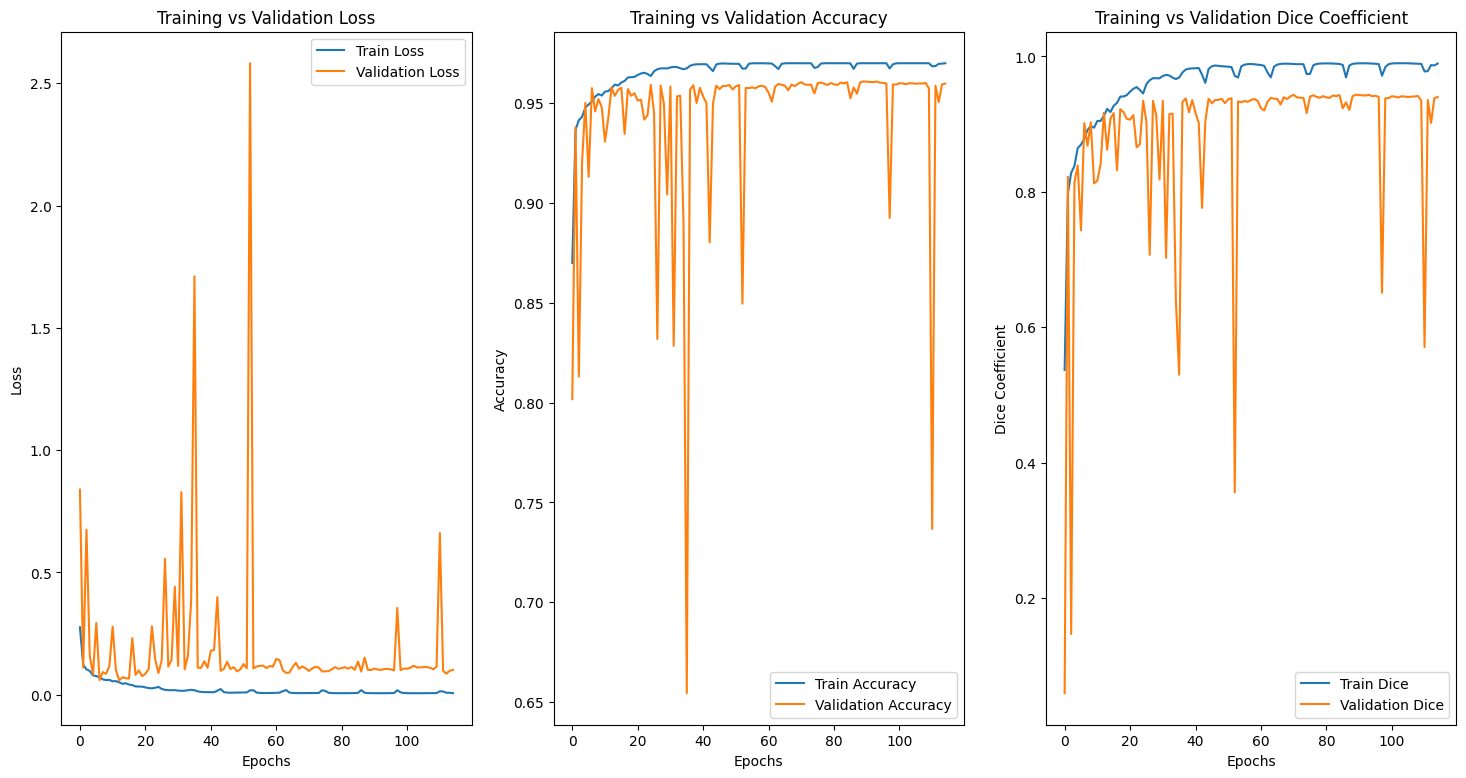

In [32]:
""" plotting the loss and accuracy during training and validation """
plt.figure(figsize=(18, 9))
plt.subplot(1, 3, 1)
plt.plot(unetFuzzy_history.history['loss'])
plt.plot(unetFuzzy_history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.subplot(1, 3, 2)
plt.plot(unetFuzzy_history.history['accuracy'])
plt.plot(unetFuzzy_history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.subplot(1, 3, 3)
plt.plot(unetFuzzy_history.history['dice_coefficient'])
plt.plot(unetFuzzy_history.history['val_dice_coefficient'])
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Training vs Validation Dice Coefficient')
plt.legend(['Train Dice', 'Validation Dice'])


## Apaga alguns dados da memória

In [32]:
del unet_history
del train_data, test_data
del unet
gc.collect()

33

## Carregando modelo

In [33]:
""" Carregando o modelo salvo """
modelo = keras.models.load_model('modelos/unetFuzzyClasses_model.keras', custom_objects={'dice_coefficient': dice_coefficient, 'dice_loss': dice_loss})

In [ ]:
""" Carregando o modelo salvo com camadas fuzzy personalizadas """
modelo = keras.models.load_model(
    'modelos/unetFuzzy_model.keras',
    custom_objects={
        'dice_coefficient': dice_coefficient,
        'dice_loss': dice_loss,
        'FuzzyBottleneckModule': FuzzyBottleneckModule,
        'FuzzificationLayer': FuzzificationLayer,
        'FuzzyInferenceLayer': FuzzyInferenceLayer,
        'DefuzzificationLayer': DefuzzificationLayer,
    },
    safe_mode=False,
)

## Testando em em X_test

In [34]:
""" Testando outras imagens """
path_x_new = 'banco2/TreinoGeral/AOL/validacaoUnetCategorical/x_test/'
path_y_new = 'banco2/TreinoGeral/AOL/validacaoUnetCategorical/y_test/'



x_new, nomes_x_new = banco(path_x_new, resolution=(256,256), grayscale= True, nomes= True)
y_new, nomes_y_new = banco(path_y_new, resolution=(256,256), grayscale= True, nomes= True)

# dict_x_new, x_new_mod = modificacoes1(x_new,
#              nomes_x_new,
#              original = True,
#              brilho = 1.7,
#              escura= 0.5)

# y_new_m, y_new_nomes = modificacoes2(dict(zip(nomes_y_new, y_new)), dict_x_new.keys())


# x_new_m = np.array(x_new_mod)
# y_new_m = np.array(y_new_m)


# print(f'Novas imagens : {x_new_m.shape}')
# print(f'Novos rótulos : {y_new_m.shape}')

class_test = (
    np.array([[0,1] if nome[2:3] == '6' else [1,0] for nome in nomes_y_new])
)


new_data = tf.data.Dataset.from_tensor_slices(((x_new, class_test), y_new))
# new_data = tf.data.Dataset.from_tensor_slices((x_new, y_new))
new_data = new_data.batch(batch_size).prefetch(AUTOTUNE)
modelo.evaluate(new_data, verbose= 1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9545 - dice_coefficient: 0.9633 - loss: 0.0532


[0.053169846534729004, 0.9545266032218933, 0.9632734656333923]

idx=0 | area_demarcada=49.343 cm² | area_pred=49.198 cm² | diff=+0.145 cm² | dice=0.9891 | iou=0.9785 | classe=Caracu


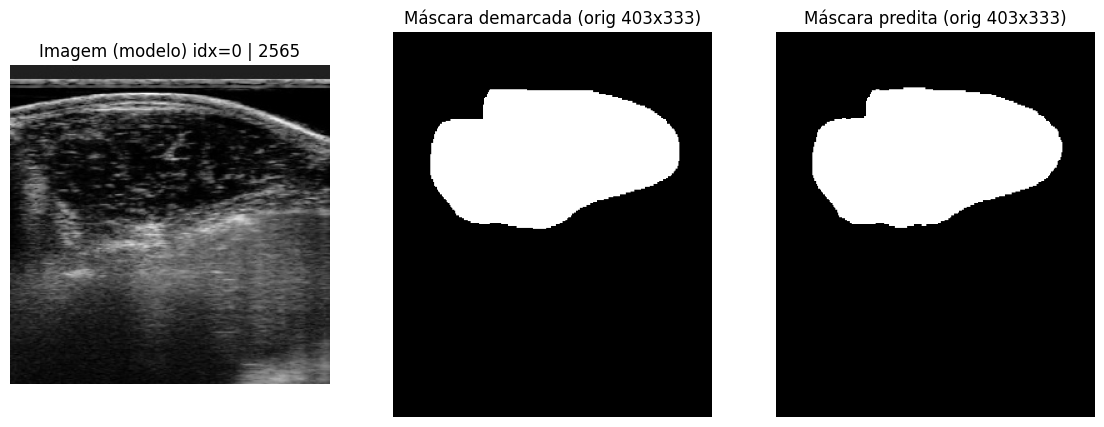

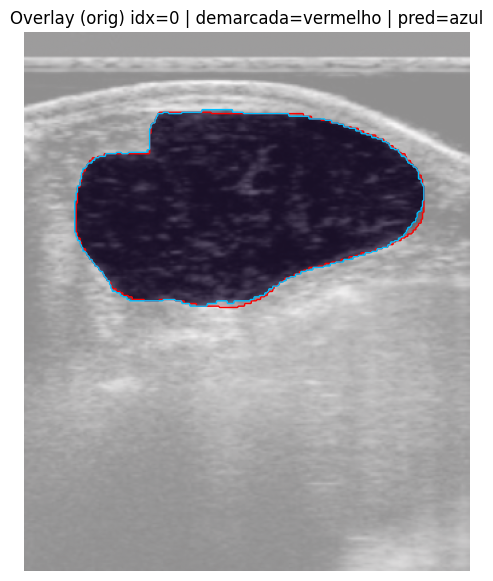

idx=1 | area_demarcada=36.402 cm² | area_pred=36.475 cm² | diff=+0.073 cm² | dice=0.9375 | iou=0.8824 | classe=Nelore


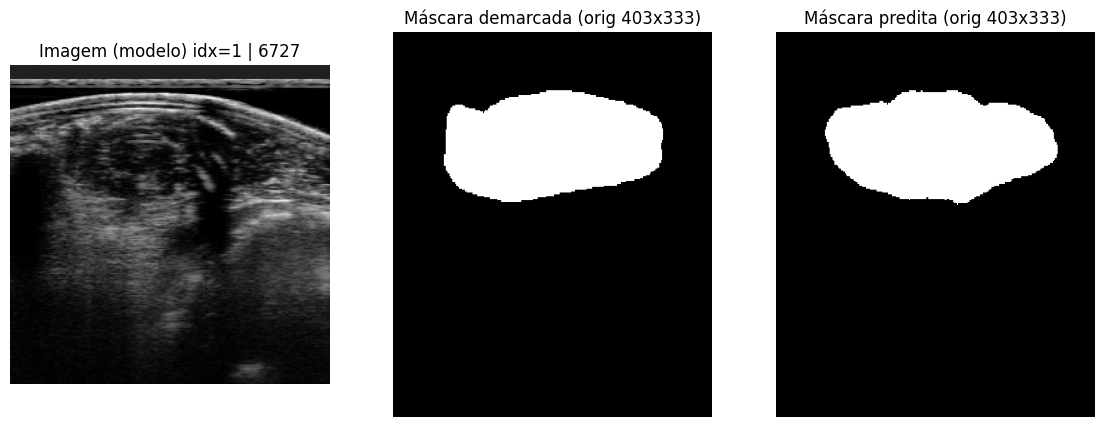

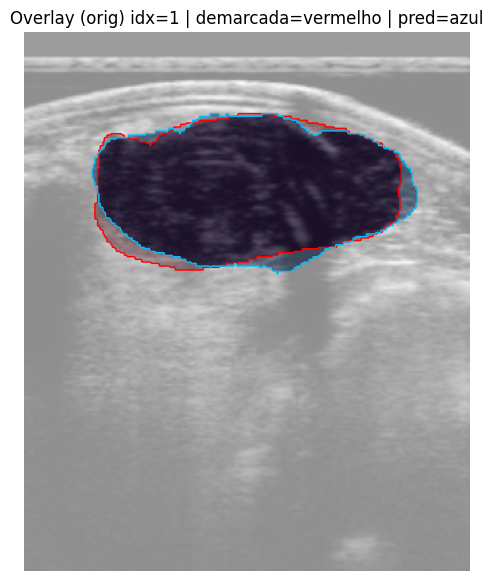

idx=2 | area_demarcada=35.491 cm² | area_pred=35.738 cm² | diff=+0.247 cm² | dice=0.9793 | iou=0.9594 | classe=Nelore


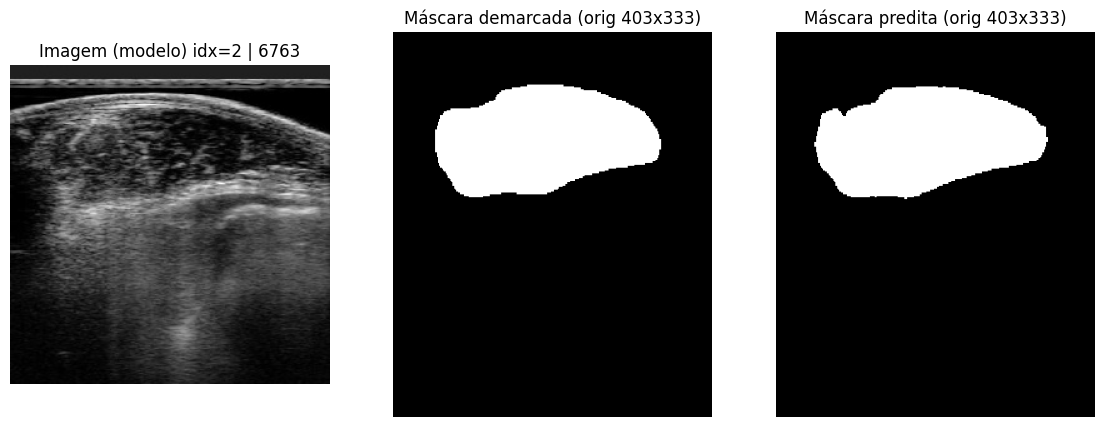

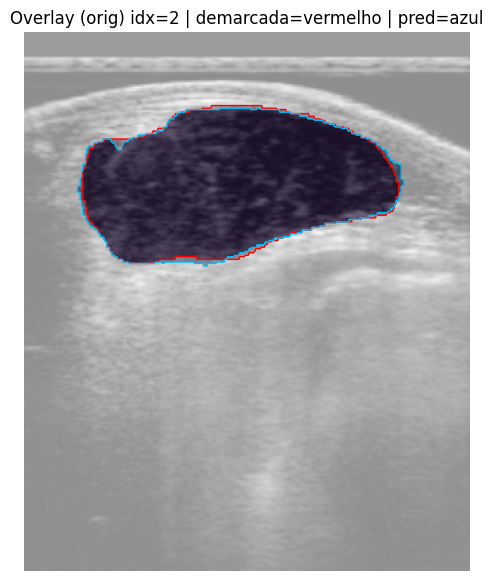

idx=3 | area_demarcada=47.106 cm² | area_pred=49.633 cm² | diff=+2.528 cm² | dice=0.9645 | iou=0.9314 | classe=Nelore


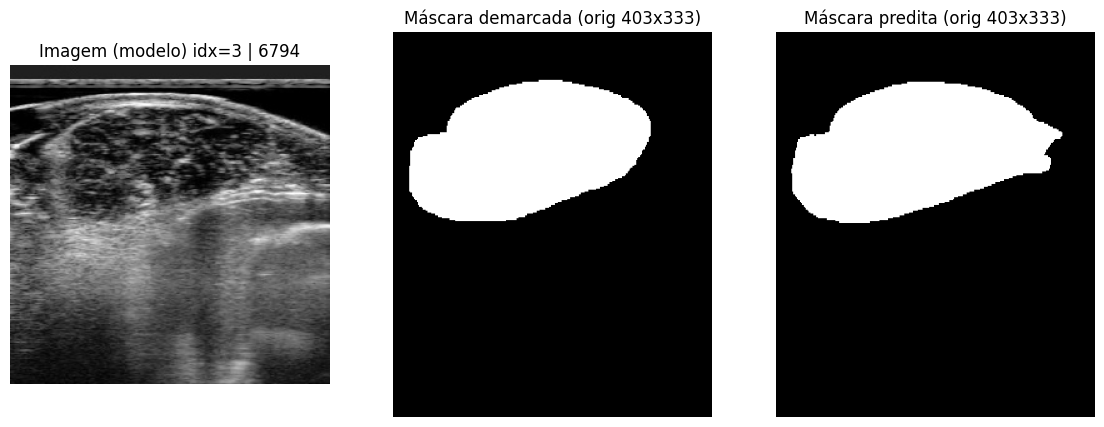

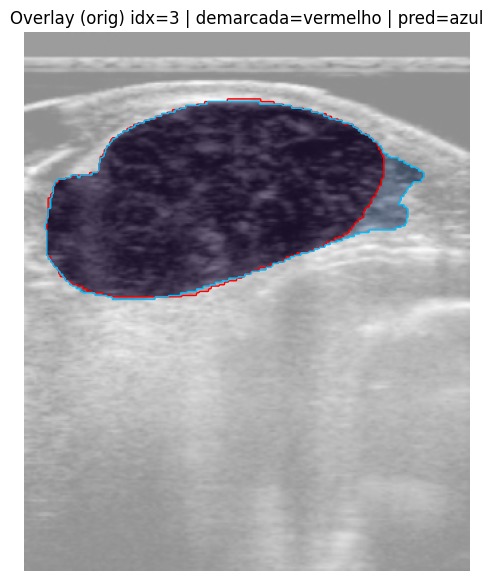

idx=4 | area_demarcada=42.332 cm² | area_pred=42.875 cm² | diff=+0.543 cm² | dice=0.9647 | iou=0.9318 | classe=Nelore


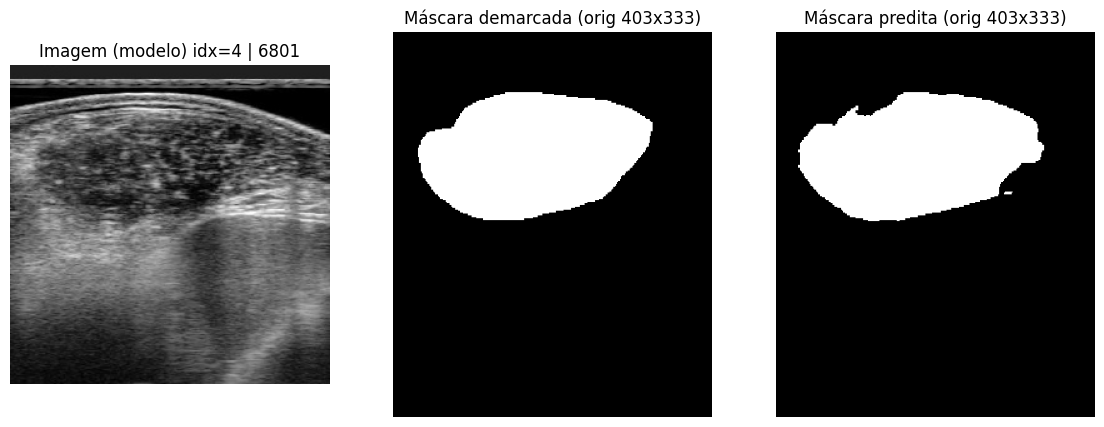

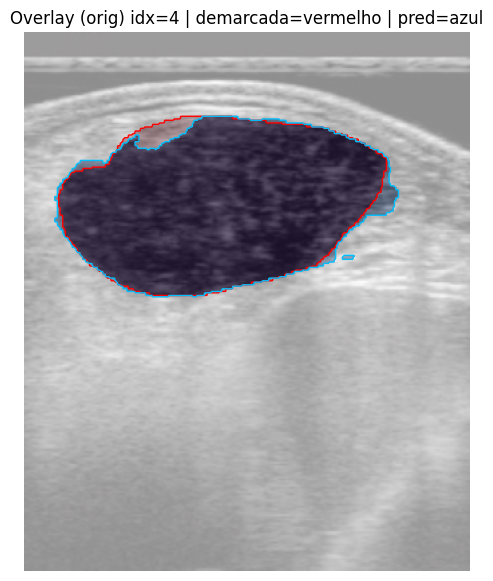

idx=5 | area_demarcada=36.997 cm² | area_pred=39.424 cm² | diff=+2.427 cm² | dice=0.9531 | iou=0.9104 | classe=Nelore


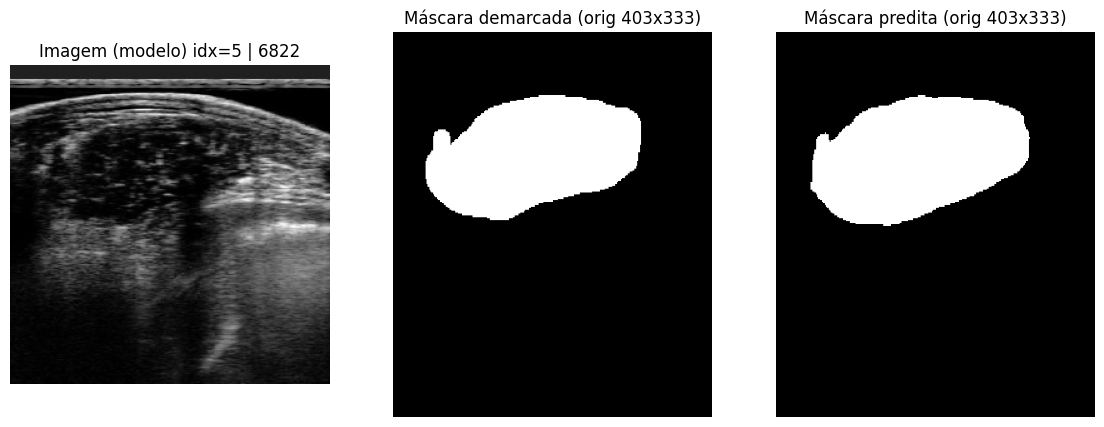

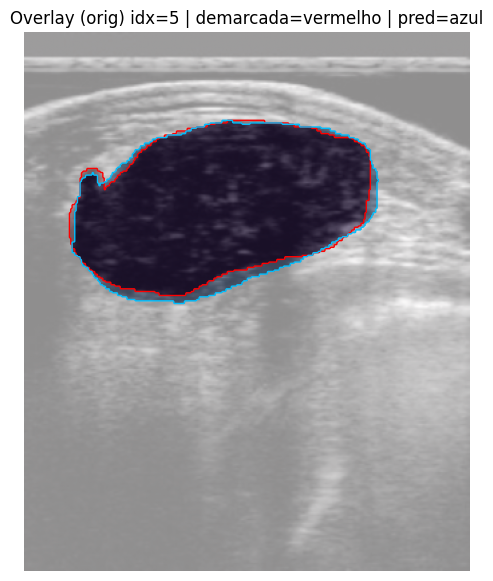

idx=6 | area_demarcada=40.458 cm² | area_pred=45.926 cm² | diff=+5.469 cm² | dice=0.9303 | iou=0.8696 | classe=Nelore


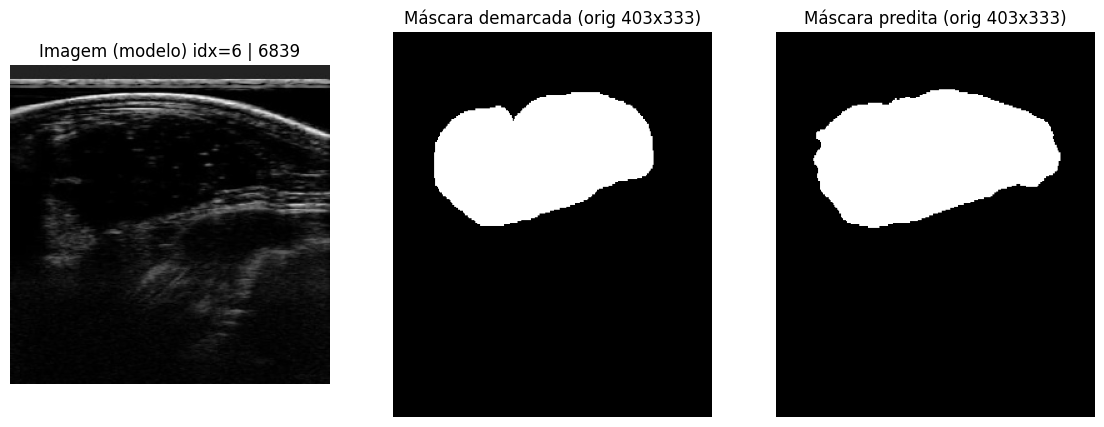

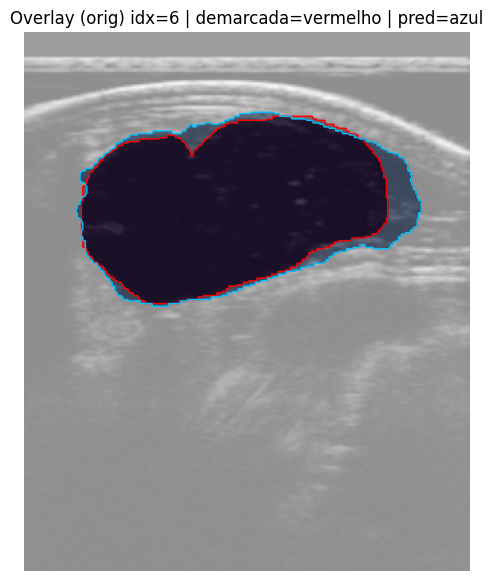

idx=7 | area_demarcada=39.562 cm² | area_pred=40.548 cm² | diff=+0.985 cm² | dice=0.9255 | iou=0.8614 | classe=Nelore


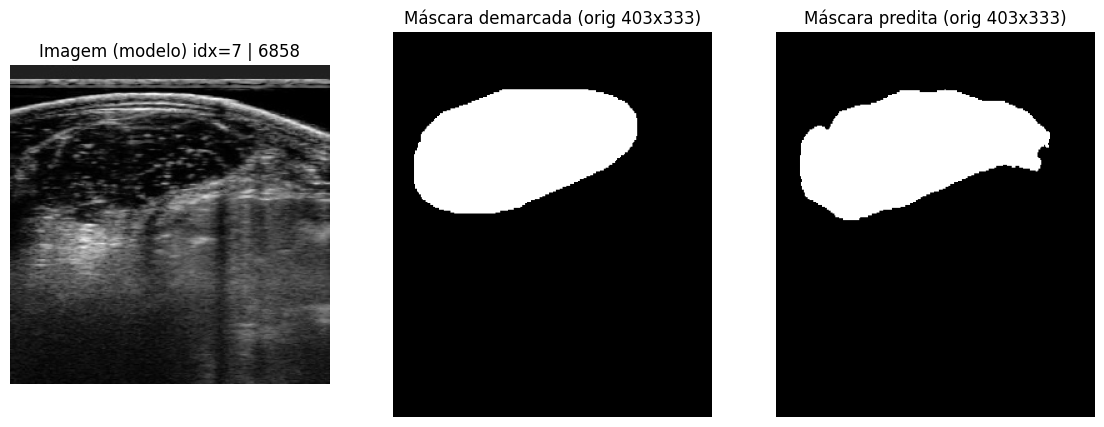

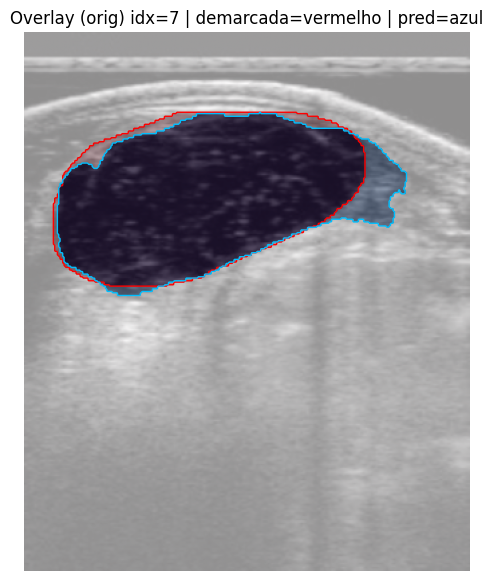

idx=8 | area_demarcada=36.665 cm² | area_pred=36.352 cm² | diff=+0.313 cm² | dice=0.9781 | iou=0.9570 | classe=Nelore


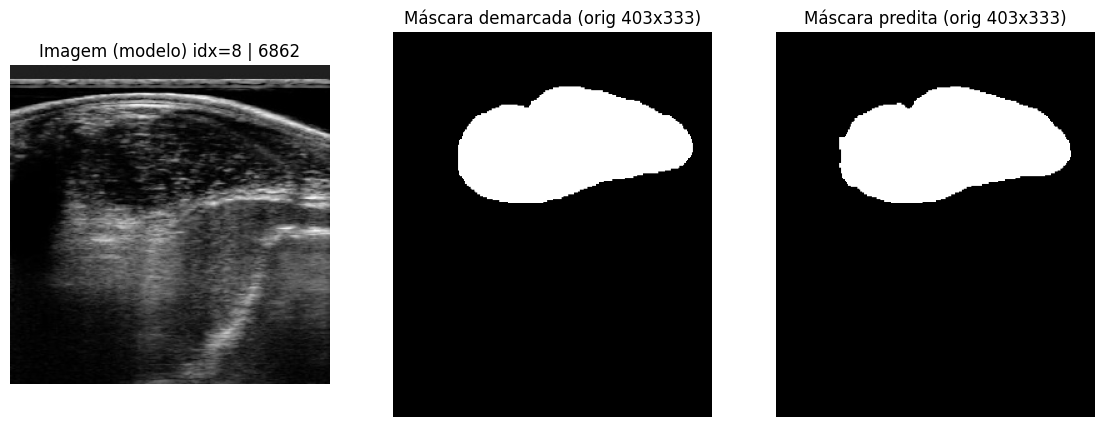

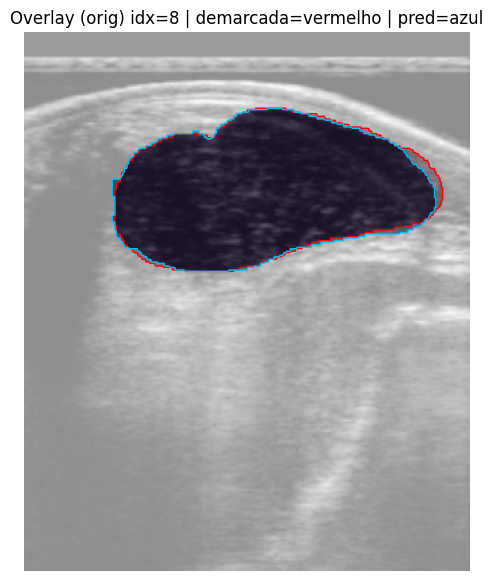

idx=9 | area_demarcada=41.583 cm² | area_pred=39.970 cm² | diff=+1.613 cm² | dice=0.9672 | iou=0.9365 | classe=Nelore


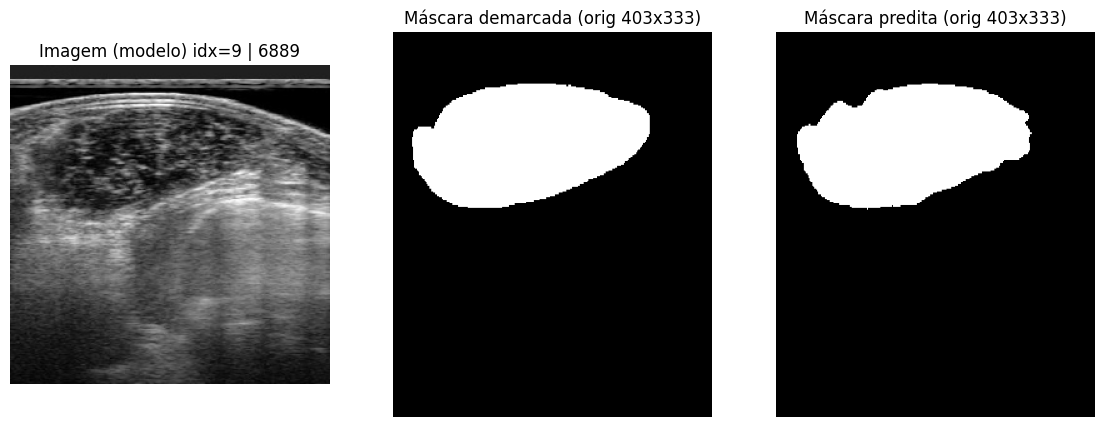

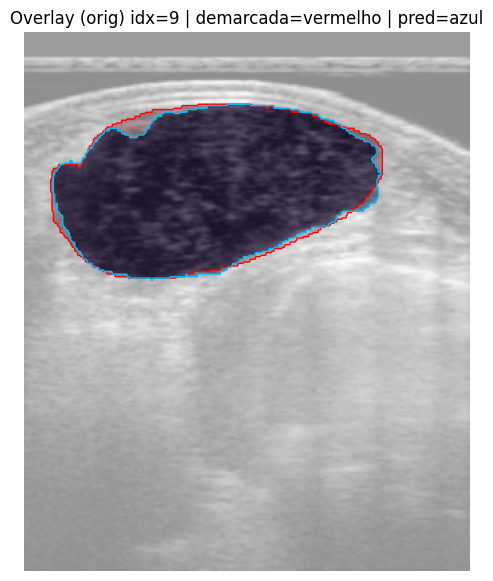

idx=10 | area_demarcada=29.891 cm² | area_pred=30.024 cm² | diff=+0.133 cm² | dice=0.9880 | iou=0.9763 | classe=Nelore


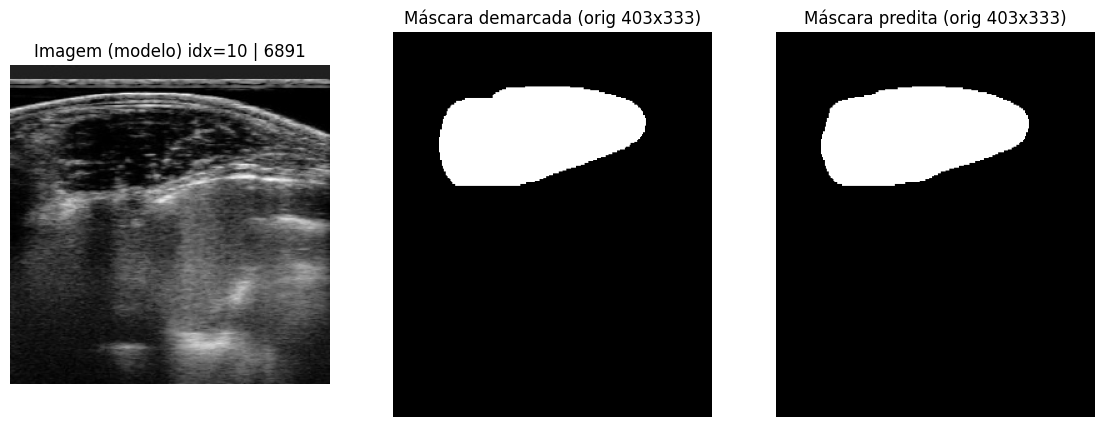

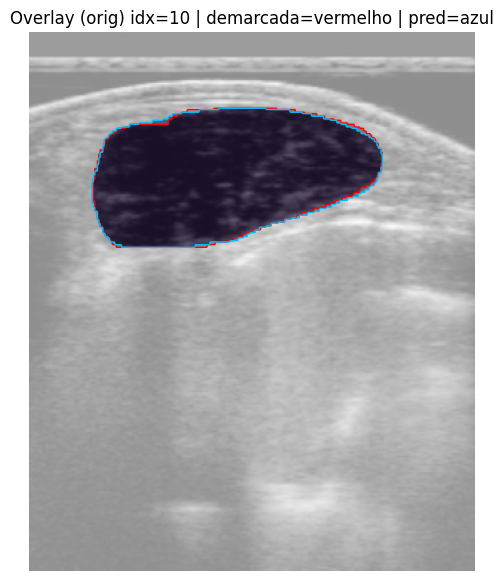

idx=11 | area_demarcada=37.706 cm² | area_pred=38.297 cm² | diff=+0.591 cm² | dice=0.9884 | iou=0.9772 | classe=Nelore


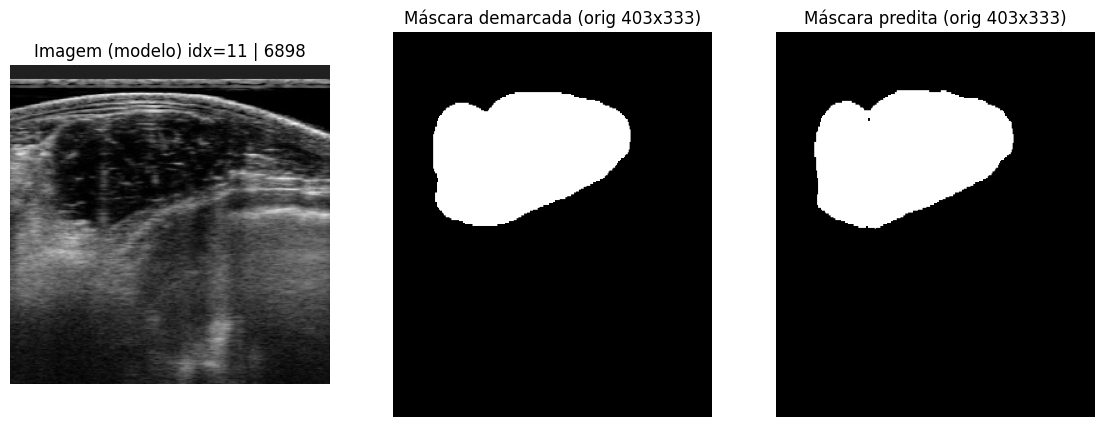

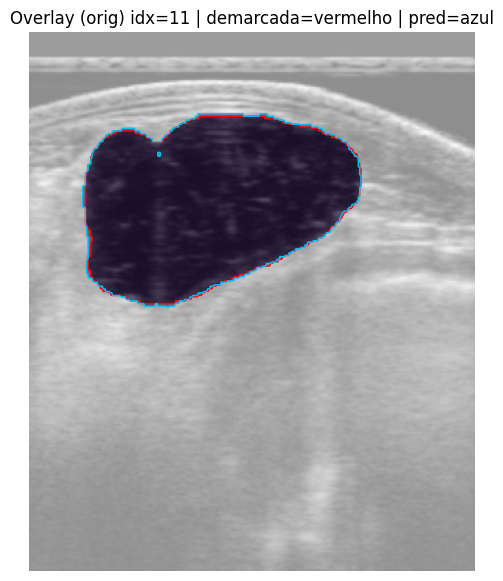

idx=12 | area_demarcada=42.152 cm² | area_pred=41.360 cm² | diff=+0.792 cm² | dice=0.9863 | iou=0.9730 | classe=Nelore


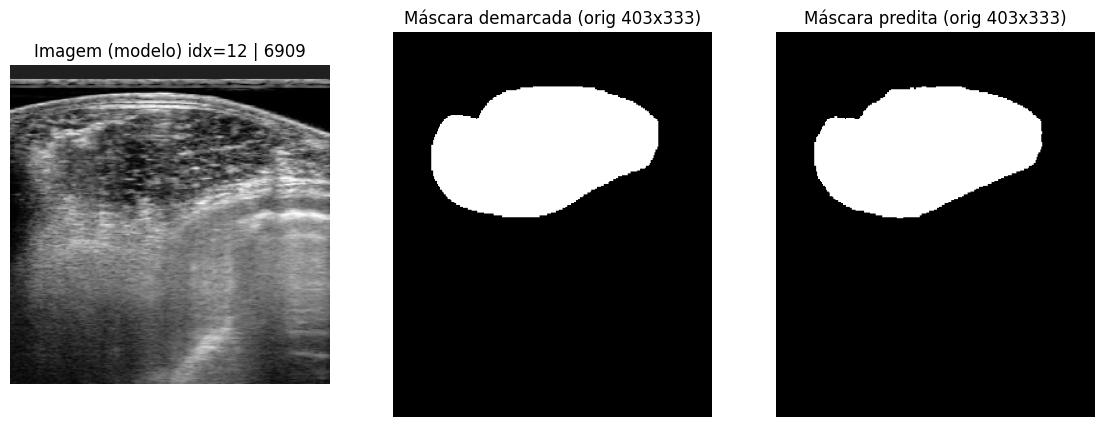

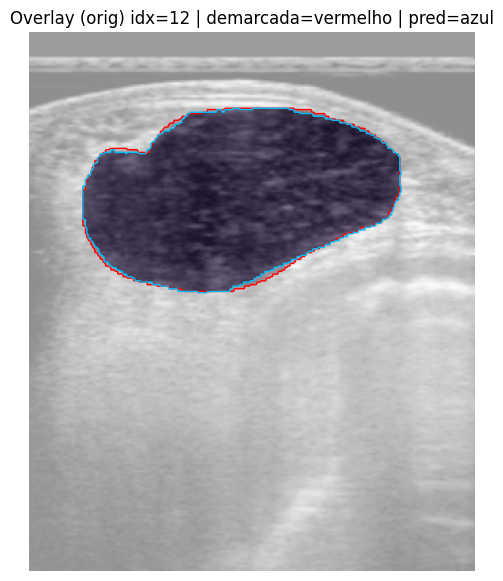

idx=13 | area_demarcada=40.047 cm² | area_pred=39.495 cm² | diff=+0.552 cm² | dice=0.9824 | iou=0.9654 | classe=Nelore


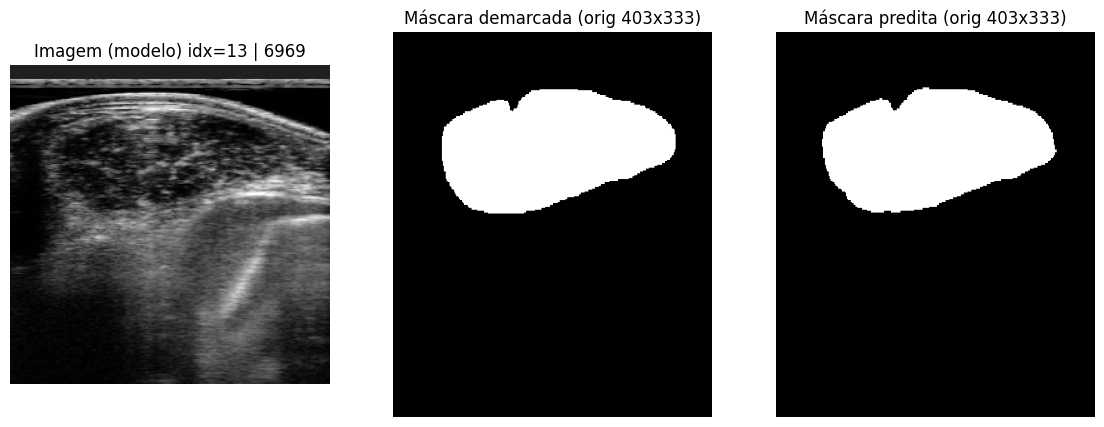

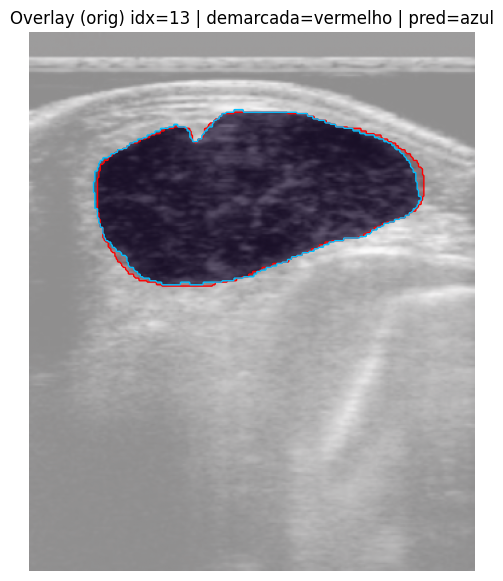

In [35]:
# Print função
for idx in range(len(x_new)):
    comparar_area_predicao_multitask(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        nomes_dados= nomes_y_new,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=True,
        overlay_alpha=0.35,
        contours=True,
        verbose=True,
    )

In [36]:
erros2 = []
iou = []
area_predita = []
area_demarcada = []
for idx in range(len(x_new)):
    resultado2 = comparar_area_predicao_multitask(
        idx,
        modelo,
        (x_new, class_test),
        y_new,
        nomes_dados=None,
        orig_size=(403, 333),
        threshold=0.5,
        px_per_cm=24.05,
        smooth=1e-6,
        plot=False,
        overlay_alpha=0.35,
        contours=True,
        verbose=False,
    )
    erros2.append(resultado2['diff_cm2'])
    iou.append(resultado2['iou_orig'])
    area_predita.append(resultado2['area_pred_cm2'])
    area_demarcada.append(resultado2['area_true_cm2'])
# Print dos erros
print(f'Erro médio nas novas imagens: {np.mean(np.abs(erros2)):.3f} cm²')
print(f'Erro Máximo nas novas imagens: {np.max(np.abs(erros2)):.3f} cm²')
print(f'Erro mínimo nas novas imagens: {np.min(np.abs(erros2)):.3f} cm²')
print(f'MAE = {sum(erros2)/len(erros2):.3f} cm²')
print(f'IoU médio nas novas imagens: {np.mean(iou):.4f}')
print(f'Área média predita nas novas imagens: {np.mean(area_predita):.3f} cm²')
print(f'Área média demarcada nas novas imagens: {np.mean(area_demarcada):.3f} cm²')

Erro médio nas novas imagens: 1.172 cm²
Erro Máximo nas novas imagens: 5.469 cm²
Erro mínimo nas novas imagens: 0.073 cm²
MAE = 1.172 cm²
IoU médio nas novas imagens: 0.9365
Área média predita nas novas imagens: 40.380 cm²
Área média demarcada nas novas imagens: 39.695 cm²


##  Calculando o R^2 

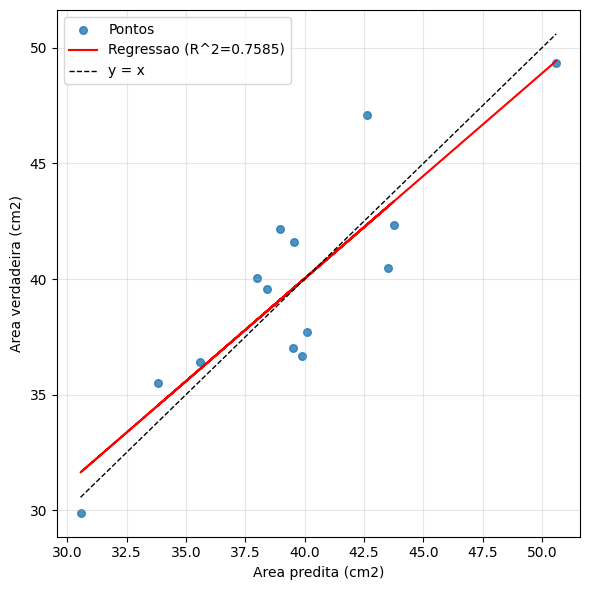

In [17]:
y_pred = np.array(area_predita)
y_true = np.array(area_demarcada)

# Ajuste de reta (y = a*x + b)
a, b = np.polyfit(y_pred, y_true, 1)
y_hat = a * y_pred + b

# R^2
y_mean = y_true.mean()
ss_tot = np.sum((y_true - y_mean) ** 2)
ss_res = np.sum((y_true - y_hat) ** 2)
r2 = 1.0 - (ss_res / ss_tot) if ss_tot != 0 else 0.0

plt.figure(figsize=(6, 6))
plt.scatter(y_pred, y_true, s=30, alpha=0.8, label="Pontos")
plt.plot(y_pred, y_hat, "r-", label=f"Regressao (R^2={r2:.4f})")
plt.plot([y_pred.min(), y_pred.max()],
         [y_pred.min(), y_pred.max()],
         "k--", linewidth=1, label="y = x")

plt.xlabel("Area predita (cm2)")
plt.ylabel("Area verdadeira (cm2)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Erro médio nas novas imagens: 3.728 cm²
Erro Máximo nas novas imagens: 9.784 cm²
Erro mínimo nas novas imagens: 0.213 cm²
